# Анализ успешных few-shot прогонов (14.05) — полное логирование

**Источник:** `tasks/jailbreak_detection/results/metrics_jailbreak_successful_14_05_full_rows.json`

Полные строки `metrics.json` (как в Kaggle `METRICS_JSON`): `extra` с `prediction_summary`, `eval_counts`, `data_summary`, `scores_eval_summary`, `timings`.

**Пресеты (27 строк):**
- `classic-medium` — 9 конфигураций (10 / 20 / 50 shots × seeds 42, 123, 456)
- `nn-medium` — 9 конфигураций
- `zero-shot-encoders` — 9 конфигураций (few-shot grid для сравнения; см. §2a)

**Eval:** WildJailbreak binary, n=2210 — `adversarial_harmful` (2000) + `adversarial_benign` (210). `recall_vanilla_harmful` везде `null`.


## 1. Загрузка и развёртка nested `extra`


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "results").exists():
    TASK_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "results").exists():
    TASK_ROOT = NOTEBOOK_DIR.parent
else:
    TASK_ROOT = Path("tasks/jailbreak_detection")

METRICS_PATH = TASK_ROOT / "results" / "metrics_jailbreak_successful_14_05_full_rows.json"
assert METRICS_PATH.is_file(), METRICS_PATH

PRESET_COLORS = {
    "classic-medium": "#2ecc71",
    "nn-medium": "#e74c3c",
    "zero-shot-encoders": "#3498db",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


def flatten_row(row: dict) -> dict:
    ex = row.get("extra") or {}
    ec = ex.get("eval_counts") or {}
    ps = ex.get("prediction_summary") or {}
    bdt = ps.get("by_data_type") or {}
    ah = bdt.get("adversarial_harmful") or {}
    ab = bdt.get("adversarial_benign") or {}
    ss = ex.get("scores_eval_summary") or {}
    tm = ex.get("timings") or {}
    align = (ex.get("data_summary") or {}).get("alignment") or {}

    return {
        "model_name": row.get("model_name"),
        "preset": ex.get("preset"),
        "search_space_preset": ex.get("search_space_preset"),
        "mode": row.get("mode"),
        "n_shots": row.get("n_shots"),
        "seed": row.get("seed"),
        "timestamp": row.get("timestamp"),
        "f1": row.get("f1"),
        "precision": row.get("precision"),
        "recall": row.get("recall"),
        "over_refusal_rate": row.get("over_refusal_rate"),
        "recall_adversarial_harmful": row.get("recall_adversarial_harmful"),
        "embedder_hf_model": ex.get("embedder_hf_model"),
        "tp": ec.get("tp"),
        "fp": ec.get("fp"),
        "fn": ec.get("fn"),
        "tn": ec.get("tn"),
        "fnr_jailbreak": ec.get("fnr_jailbreak"),
        "fpr_safe": ec.get("fpr_safe"),
        "n_eval": ec.get("n_eval"),
        "raw_none_count": ps.get("raw_none_count"),
        "pred_safe": ps.get("pred_safe"),
        "pred_jailbreak": ps.get("pred_jailbreak"),
        "harmful_n": ah.get("n"),
        "harmful_accuracy": ah.get("accuracy"),
        "harmful_pred_jb_rate": ah.get("pred_jailbreak_rate"),
        "benign_n": ab.get("n"),
        "benign_accuracy": ab.get("accuracy"),
        "benign_pred_jb_rate": ab.get("pred_jailbreak_rate"),
        "margin_mean": ss.get("margin_mean"),
        "margin_std": ss.get("margin_std"),
        "margin_min": ss.get("margin_min"),
        "margin_max": ss.get("margin_max"),
        "score_safe_mean": ss.get("score_col0_mean"),
        "score_jb_mean": ss.get("score_col1_mean"),
        "train_sec": tm.get("train_total_sec"),
        "eval_sec": tm.get("eval_total_sec"),
        "aligned_lengths": align.get("aligned_lengths"),
    }


rows = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
df = pd.DataFrame([flatten_row(r) for r in rows])
df = df.sort_values(["preset", "n_shots", "seed"]).reset_index(drop=True)

print("Строк:", len(df))
print("Пресеты:", sorted(df["preset"].dropna().unique()))
print("Embedder unique:", df["embedder_hf_model"].dropna().unique().tolist())
print("raw_none_count max:", df["raw_none_count"].max())
df.groupby("preset").agg(n=("f1", "count"), f1_mean=("f1", "mean"), f1_nunique=("f1", "nunique")).round(4)


Строк: 27
Пресеты: ['classic-medium', 'nn-medium', 'zero-shot-encoders']
Embedder unique: ['intfloat/multilingual-e5-large-instruct']
raw_none_count max: 0


,n,f1_mean,f1_nunique
preset,,,
classic-medium,9,0.7413,9
nn-medium,9,0.5686,9
zero-shot-encoders,9,0.9133,1


## 2a. `zero-shot-encoders`: инвариантность к seed и n_shots


In [2]:
zs = df[df["preset"] == "zero-shot-encoders"].copy()
metric_cols = ["f1", "recall", "over_refusal_rate", "harmful_accuracy", "benign_pred_jb_rate", "margin_mean", "tp", "fp", "fn", "tn"]

print("zero-shot строк:", len(zs))
print("Уникальных значений F1:", zs["f1"].nunique())
print(zs.groupby(["n_shots", "seed"])[metric_cols].nunique().max())

# Одна операционная точка — дублируем 9 раз в grid
zs_point = zs.drop_duplicates(subset=metric_cols).iloc[0]
print("\nЕдинственная точка zero-shot:")
print(
    f"  F1={zs_point['f1']:.4f}  recall={zs_point['recall']:.3f}  ORR={zs_point['over_refusal_rate']:.3f}\n"
    f"  harmful_acc={zs_point['harmful_accuracy']:.3f}  benign_pred_JB={zs_point['benign_pred_jb_rate']:.3f}\n"
    f"  TP={int(zs_point['tp'])} FP={int(zs_point['fp'])} FN={int(zs_point['fn'])} TN={int(zs_point['tn'])}\n"
    f"  margin_mean={zs_point['margin_mean']:.4f}  embedder={zs_point['embedder_hf_model']}"
)


zero-shot строк: 9
Уникальных значений F1: 1
f1                     1
recall                 1
over_refusal_rate      1
harmful_accuracy       1
benign_pred_jb_rate    1
margin_mean            1
tp                     1
fp                     1
fn                     1
tn                     1
dtype: int64

Единственная точка zero-shot:
  F1=0.9133  recall=0.908  ORR=0.767
  harmful_acc=0.908  benign_pred_JB=0.767
  TP=1816 FP=161 FN=184 TN=49
  margin_mean=0.0105  embedder=intfloat/multilingual-e5-large-instruct


## 2. Сводка по пресетам и shots (mean ± std по seeds)


In [3]:
summary_cols = [
    "f1", "precision", "recall", "over_refusal_rate",
    "harmful_accuracy", "benign_pred_jb_rate",
    "fnr_jailbreak", "margin_mean", "train_sec", "eval_sec",
]
agg = (
    df.groupby(["preset", "n_shots"])[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)
agg


f1         precision          recall          \
                              mean     std      mean     std    mean     std   
preset             n_shots                                                     
classic-medium     10       0.7568  0.0259    0.9242  0.0446  0.6422  0.0388   
                   20       0.7960  0.0625    0.9314  0.0165  0.7007  0.1084   
                   50       0.6710  0.1041    0.9320  0.0197  0.5332  0.1299   
nn-medium          10       0.2255  0.3430    0.8883  0.0944  0.1668  0.2647   
                   20       0.7926  0.1731    0.9021  0.0038  0.7365  0.2690   
                   50       0.6875  0.1572    0.9048  0.0045  0.5753  0.2242   
zero-shot-encoders 10       0.9133  0.0000    0.9186  0.0000  0.9080  0.0000   
                   20       0.9133  0.0000    0.9186  0.0000  0.9080  0.0000   
                   50       0.9133  0.0000    0.9186  0.0000  0.9080  0.0000   

                           over_refusal_rate         harmful_accuracy          \
                                        mean     std             mean     std   
preset             n_shots                                                      
classic-medium     10                 0.5175  0.3507           0.6422  0.0388   
                   20                 0.5048  0.2089           0.7007  0.1084   
                   50                 0.3873  0.1797           0.5332  0.1299   
nn-medium          10                 0.1635  0.2546           0.1668  0.2647   
                   20                 0.7540  0.2526           0.7365  0.2690   
                   50                 0.5762  0.2268           0.5753  0.2242   
zero-shot-encoders 10                 0.7667  0.0000           0.9080  0.0000   
                   20                 0.7667  0.0000           0.9080  0.0000   
                   50                 0.7667  0.0000           0.9080  0.0000   

                           benign_pred_jb_rate         fnr_jailbreak          \
                                          mean     std          mean     std   
preset             n_shots                                                     
classic-medium     10                   0.5175  0.3507        0.3578  0.0388   
                   20                   0.5048  0.2089        0.2993  0.1084   
                   50                   0.3873  0.1797        0.4668  0.1299   
nn-medium          10                   0.1635  0.2546        0.8332  0.2647   
                   20                   0.7540  0.2526        0.2635  0.2690   
                   50                   0.5762  0.2268        0.4247  0.2242   
zero-shot-encoders 10                   0.7667  0.0000        0.0920  0.0000   
                   20                   0.7667  0.0000        0.0920  0.0000   
                   50                   0.7667  0.0000        0.0920  0.0000   

                           margin_mean         train_sec          eval_sec  \
                                  mean     std      mean      std     mean   
preset             n_shots                                                   
classic-medium     10           0.1027  0.0394   92.6396  38.2536   0.1152   
                   20           0.0497  0.0775  111.6573   2.3408   0.1543   
                   50           0.0348  0.1174  136.5410   1.7360   0.1669   
nn-medium          10          -0.3332  0.5225   66.9629   0.1727   0.4816   
                   20           0.1031  0.1256   67.6892   0.4542   0.3995   
                   50           0.0191  0.0757   73.0549   0.6704   0.4605   
zero-shot-encoders 10           0.0105  0.0000   84.9147  38.7583   0.0991   
                   20           0.0105  0.0000   65.0115   0.6182   0.1011   
                   50           0.0105  0.0000   72.0514   0.4787   0.1018   

                                    
                               std  
preset             n_shots          
classic-medium     10       0.0105  
                   20       0.0519  
               

## 3. Метрики по подтипам WildJailbreak (`by_data_type`)


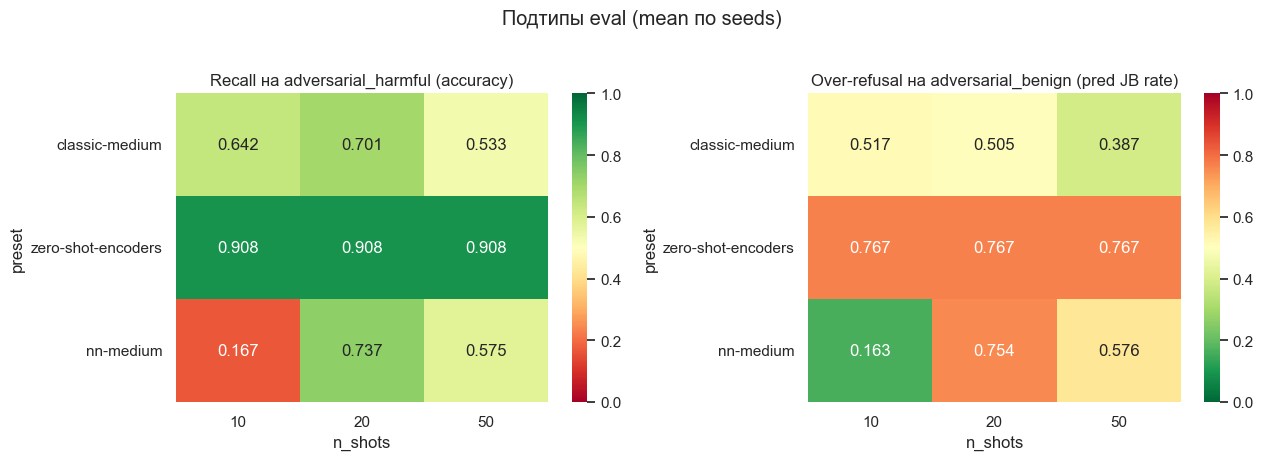

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
presets_order = ["classic-medium", "zero-shot-encoders", "nn-medium"]

for ax, col, title, cmap_rev in zip(
    axes,
    ["harmful_accuracy", "benign_pred_jb_rate"],
    [
        "Recall на adversarial_harmful (accuracy)",
        "Over-refusal на adversarial_benign (pred JB rate)",
    ],
    [False, True],
):
    pivot = df.pivot_table(index="preset", columns="n_shots", values=col, aggfunc="mean")
    pivot = pivot.reindex(index=presets_order, columns=sorted(pivot.columns))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r" if cmap_rev else "RdYlGn",
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlabel("n_shots")

plt.suptitle("Подтипы eval (mean по seeds)", y=1.02)
plt.tight_layout()
plt.show()


## 4. Confusion matrix агрегаты и trade-off


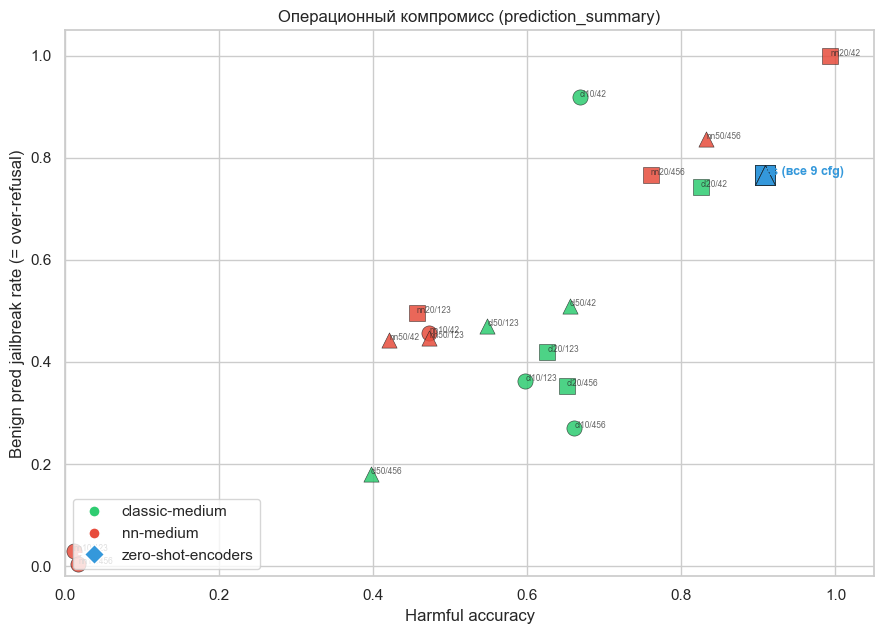

max |recall - harmful_accuracy|: 0.0
max |ORR - benign_pred_jb_rate|: 0.0


In [5]:
fig, ax = plt.subplots(figsize=(9, 6.5))
markers = {10: "o", 20: "s", 50: "^"}

for _, row in df.iterrows():
    preset = row["preset"]
    ax.scatter(
        row["harmful_accuracy"],
        row["benign_pred_jb_rate"],
        c=PRESET_COLORS[preset],
        marker=markers[int(row["n_shots"])],
        s=120 if preset != "zero-shot-encoders" else 200,
        edgecolors="k",
        linewidths=0.4,
        alpha=0.85 if preset != "zero-shot-encoders" else 1.0,
    )

# Подпись одной точки zero-shot (остальные совпадают)
zs0 = df[df["preset"] == "zero-shot-encoders"].iloc[0]
ax.scatter([], [], c=PRESET_COLORS["zero-shot-encoders"], marker="D", s=200, label="zero-shot (1 точка)")

for _, row in df[df["preset"] != "zero-shot-encoders"].iterrows():
    ax.annotate(
        f"{row['preset'][:2]}{int(row['n_shots'])}/{int(row['seed'])}",
        (row["harmful_accuracy"], row["benign_pred_jb_rate"]),
        fontsize=6,
        alpha=0.7,
    )
ax.annotate(
    "zs (все 9 cfg)",
    (zs0["harmful_accuracy"], zs0["benign_pred_jb_rate"]),
    fontsize=9,
    fontweight="bold",
    color=PRESET_COLORS["zero-shot-encoders"],
)

ax.set_xlabel("Harmful accuracy")
ax.set_ylabel("Benign pred jailbreak rate (= over-refusal)")
ax.set_title("Операционный компромисс (prediction_summary)")
ax.legend(handles=[
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=PRESET_COLORS["classic-medium"], markersize=8, label="classic-medium"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=PRESET_COLORS["nn-medium"], markersize=8, label="nn-medium"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor=PRESET_COLORS["zero-shot-encoders"], markersize=10, label="zero-shot-encoders"),
], loc="lower left")
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

df["recall_minus_harmful_acc"] = df["recall"] - df["harmful_accuracy"]
df["orr_minus_benign_jb"] = df["over_refusal_rate"] - df["benign_pred_jb_rate"]
print("max |recall - harmful_accuracy|:", df["recall_minus_harmful_acc"].abs().max())
print("max |ORR - benign_pred_jb_rate|:", df["orr_minus_benign_jb"].abs().max())


## 5. Scoring margin


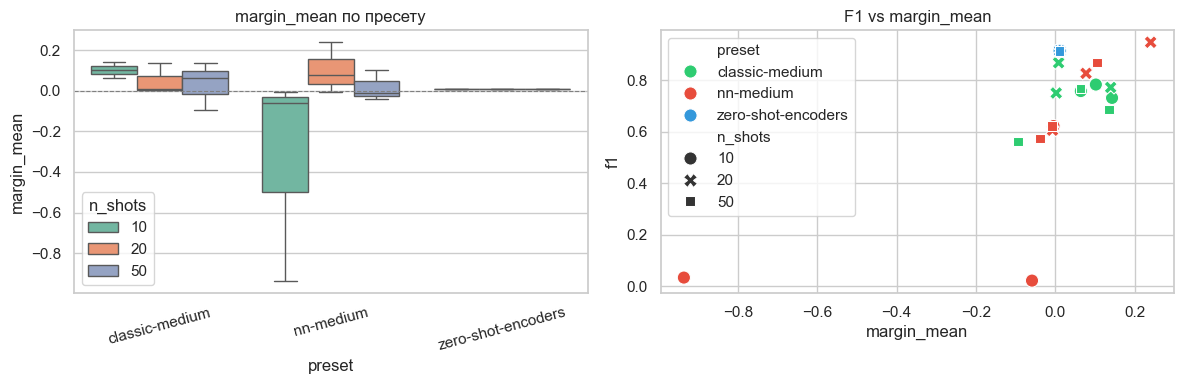

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="preset", y="margin_mean", hue="n_shots", ax=axes[0], palette="Set2")
axes[0].set_title("margin_mean по пресету")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].tick_params(axis="x", rotation=15)

sns.scatterplot(
    data=df,
    x="margin_mean",
    y="f1",
    hue="preset",
    style="n_shots",
    palette=PRESET_COLORS,
    s=90,
    ax=axes[1],
)
axes[1].set_title("F1 vs margin_mean")

plt.tight_layout()
plt.show()


## 6. Время обучения и оценки


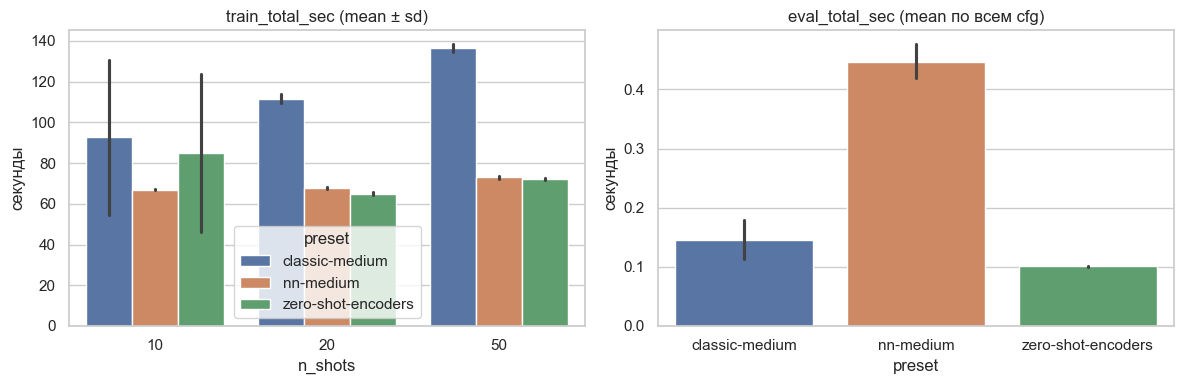

Train mean (sec): {'classic-medium': 113.6, 'nn-medium': 69.2, 'zero-shot-encoders': 74.0}
Eval mean (sec): {'classic-medium': 0.145, 'nn-medium': 0.447, 'zero-shot-encoders': 0.101}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="n_shots", y="train_sec", hue="preset", estimator=np.mean, errorbar="sd", ax=axes[0])
axes[0].set_title("train_total_sec (mean ± sd)")
axes[0].set_ylabel("секунды")

sns.barplot(data=df, x="preset", y="eval_sec", hue="preset", dodge=False, estimator=np.mean, ax=axes[1], legend=False)
axes[1].set_title("eval_total_sec (mean по всем cfg)")
axes[1].set_ylabel("секунды")
plt.tight_layout()
plt.show()

print("Train mean (sec):", df.groupby("preset")["train_sec"].mean().round(1).to_dict())
print("Eval mean (sec):", df.groupby("preset")["eval_sec"].mean().round(3).to_dict())


## 7. Лучшие / худшие конфигурации


In [8]:
# Глобальный максимум F1 (может быть ловушка ORR)
glob_best = df.loc[df["f1"].idxmax()]
print("GLOBAL max F1:", glob_best["preset"], int(glob_best["n_shots"]), "seed", int(glob_best["seed"]))
print(f"  F1={glob_best['f1']:.4f} recall={glob_best['recall']:.3f} ORR={glob_best['over_refusal_rate']:.3f} TN={int(glob_best['tn'])}")

print()

for preset in ["classic-medium", "zero-shot-encoders", "nn-medium"]:
    sub = df[df["preset"] == preset]
    best = sub.loc[sub["f1"].idxmax()]
    worst = sub.loc[sub["f1"].idxmin()]
    print("=" * 72)
    print(preset, "| embedder:", sub["embedder_hf_model"].dropna().unique().tolist())
    print(
        f"  BEST  F1={best['f1']:.4f}  {int(best['n_shots'])}shot s={int(best['seed'])}  "
        f"R={best['recall']:.3f} ORR={best['over_refusal_rate']:.3f}  margin={best['margin_mean']:.4f}  "
        f"train={best['train_sec']:.0f}s"
    )
    print(f"        TP={int(best['tp'])} FP={int(best['fp'])} FN={int(best['fn'])} TN={int(best['tn'])}")
    if sub["f1"].nunique() > 1:
        print(
            f"  WORST F1={worst['f1']:.4f}  {int(worst['n_shots'])}shot s={int(worst['seed'])}  "
            f"R={worst['recall']:.3f} ORR={worst['over_refusal_rate']:.3f}"
        )
    else:
        print("  (все 9 конфигураций идентичны по метрикам eval)")


GLOBAL max F1: nn-medium 20 seed 42
  F1=0.9466 recall=0.993 ORR=1.000 TN=0

classic-medium | embedder: ['intfloat/multilingual-e5-large-instruct']
  BEST  F1=0.8671  20shot s=42  R=0.825 ORR=0.743  margin=0.0080  train=114s
        TP=1650 FP=156 FN=350 TN=54
  WORST F1=0.5602  50shot s=456  R=0.397 ORR=0.181
zero-shot-encoders | embedder: ['intfloat/multilingual-e5-large-instruct']
  BEST  F1=0.9133  10shot s=42  R=0.908 ORR=0.767  margin=0.0105  train=130s
        TP=1816 FP=161 FN=184 TN=49
  (все 9 конфигураций идентичны по метрикам eval)
nn-medium | embedder: []
  BEST  F1=0.9466  20shot s=42  R=0.993 ORR=1.000  margin=0.2398  train=67s
        TP=1986 FP=210 FN=14 TN=0
  WORST F1=0.0217  10shot s=123  R=0.011 ORR=0.029


## 8. Сравнение пресетов (mean по seeds, по shots)


In [9]:
cmp = (
    df.groupby(["n_shots", "preset"])
    .agg(
        f1=("f1", "mean"),
        recall=("recall", "mean"),
        orr=("over_refusal_rate", "mean"),
        harmful_acc=("harmful_accuracy", "mean"),
        benign_jb=("benign_pred_jb_rate", "mean"),
        margin=("margin_mean", "mean"),
        train_s=("train_sec", "mean"),
    )
    .unstack("preset")
)
cmp.columns = [f"{a}_{b}" for a, b in cmp.columns]

# Дельты vs zero-shot (константа)
zs_f1 = df.loc[df["preset"] == "zero-shot-encoders", "f1"].iloc[0]
for p in ["classic-medium", "nn-medium"]:
    col = f"f1_{p}"
    if col in cmp.columns:
        cmp[f"delta_f1_vs_zs_{p[:2]}"] = cmp[col] - zs_f1

cmp.round(4)


,f1_classic-medium,f1_nn-medium,f1_zero-shot-encoders,recall_classic-medium,recall_nn-medium,recall_zero-shot-encoders,orr_classic-medium,orr_nn-medium,orr_zero-shot-encoders,harmful_acc_classic-medium,...,benign_jb_nn-medium,benign_jb_zero-shot-encoders,margin_classic-medium,margin_nn-medium,margin_zero-shot-encoders,train_s_classic-medium,train_s_nn-medium,train_s_zero-shot-encoders,delta_f1_vs_zs_cl,delta_f1_vs_zs_nn
n_shots,,,,,,,,,,,,,,,,,,,,,
10,0.7568,0.2255,0.9133,0.6422,0.1668,0.908,0.5175,0.1635,0.7667,0.6422,...,0.1635,0.7667,0.1027,-0.3332,0.0105,92.6396,66.9629,84.9147,-0.1565,-0.6877
20,0.7960,0.7926,0.9133,0.7007,0.7365,0.908,0.5048,0.7540,0.7667,0.7007,...,0.7540,0.7667,0.0497,0.1031,0.0105,111.6573,67.6892,65.0115,-0.1172,-0.1207
50,0.6710,0.6875,0.9133,0.5332,0.5753,0.908,0.3873,0.5762,0.7667,0.5332,...,0.5762,0.7667,0.0348,0.0191,0.0105,136.5410,73.0549,72.0514,-0.2422,-0.2257


## 9. Выводы (27 прогонов, полное логирование)

### Данные
- **27 строк:** classic (9) + nn (9) + **zero-shot-encoders (9)**.
- Eval **2210** примеров; `raw_none_count = 0` везде.
- **zero-shot:** все 9 комбинаций (shots × seed) дают **одну и ту же** операционную точку — few-shot grid не меняет zero-shot классификатор (ожидаемо).

### zero-shot-encoders (новое)
- **Embedder:** `intfloat/multilingual-e5-large-instruct` (как у classic).
- **F1 = 0.913**, **recall (harmful) = 0.908**, **ORR = 0.767** — TP=1816, FN=184, FP=161, TN=49.
- **Лучший средний F1 среди пресетов** (0.913 vs classic 0.741, nn 0.569), **выше лучшего classic** (0.867 @ 20/42).
- **Компромисс:** ORR **0.77** — ~77% adversarial_benign помечены как jailbreak; хуже classic-best (0.74), но **лучше** типичного nn и стабильнее по seeds.
- **margin_mean ≈ 0.010** — решение на пороге (как у лучшего classic 20/42).
- **eval ≈ 0.1 s**; train ~63–130 s (первый прогон дольше из‑за кэша embedder).
- **Практический смысл:** сильный **базовый** детектор без подбора shots/seed; для продакшена всё равно нужен контроль ORR (threshold / calibration).

### classic-medium (без изменений по сути)
- Средний F1 **0.741**; оптимум по shots — **20** (mean F1 0.796).
- Лучший баланс: **20 shot, seed=42** — F1 **0.867**, recall **0.825**, ORR **0.743**.
- Провалы: 50/456 (F1 0.560), 10/42 (ORR **0.92**).

### nn-medium
- Средний F1 **0.569**; нестабилен по seeds.
- **Глобальный max F1 = 0.947** (20/42), но **TN=0, ORR=1.0** — неприемлемо для safe-трафика.
- Рабочие точки: 50/456 (F1 0.867), 20/456 (F1 0.826) — с высоким ORR.

### Ранжирование (по mean F1, не по пику)
1. **zero-shot-encoders** — 0.913 (константа)
2. **classic-medium** — 0.741
3. **nn-medium** — 0.569

По **пику F1** лидирует nn (0.947), но с **полным over-refusal** safe.

### Рекомендации (обновлено)
1. **Для стабильного high-recall без перебора grid:** `zero-shot-encoders` + e5-large-instruct — F1 **0.91**, recall **0.91**; явно мониторить **ORR ~0.77**.
2. **Для тонкой настройки компромисса:** `classic-medium`, **20 shot**, seed **42** — чуть ниже F1, сопоставимый ORR, но вариативность по seeds/shots.
3. **Не выбирать nn** по max F1 без проверки TN / benign_pred_jb_rate.
4. В отчётах: `prediction_summary.by_data_type`; для zero-shot не усреднять 9 дублей как «стабильность seed» — это одна точка.

### Ограничения
- Zero-shot и classic на **одном embedder** — разница в search space / HPO, не в энкодере.
- Eval без vanilla-подмножеств; threshold не sweep'ился на val.
